# Tag 08 - Anfänger
## K-Means Customer Segmentation

In [1]:
OUTPUT_SUBDIR = "01_anfaenger"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
from pathlib import Path

PROJECT_DIR = Path.cwd()
while PROJECT_DIR.name != "Tag_08_Clustering_Project" and PROJECT_DIR.parent != PROJECT_DIR:
    PROJECT_DIR = PROJECT_DIR.parent

DATA_DIR = PROJECT_DIR / "data" / "raw"
OUT_DIR = PROJECT_DIR / "outputs" / OUTPUT_SUBDIR
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("OUT_DIR:", OUT_DIR)

PROJECT_DIR: c:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_08_Clustering_Project
DATA_DIR: c:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_08_Clustering_Project\data\raw
OUT_DIR: c:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_08_Clustering_Project\outputs\01_anfaenger


In [3]:
DATA_PATH = DATA_DIR / "Mall_Customers.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Put Mall_Customers.csv here: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
required_cols = ["Annual Income (k$)", "Spending Score (1-100)"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}\nAvailable columns: {list(df.columns)}")

X_mall = df[required_cols].copy()
print(X_mall.describe())

       Annual Income (k$)  Spending Score (1-100)
count          200.000000              200.000000
mean            60.560000               50.200000
std             26.264721               25.823522
min             15.000000                1.000000
25%             41.500000               34.750000
50%             61.500000               50.000000
75%             78.000000               73.000000
max            137.000000               99.000000


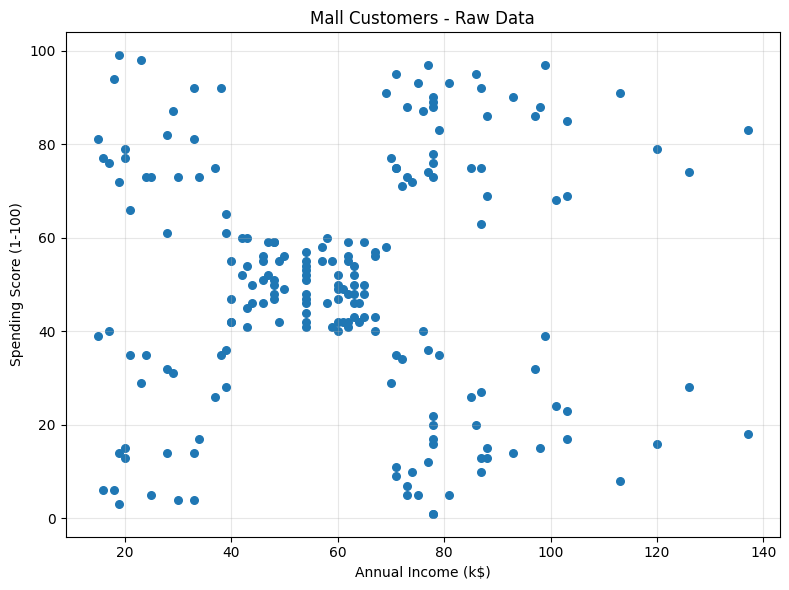

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(X_mall["Annual Income (k$)"], X_mall["Spending Score (1-100)"], s=30)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Mall Customers - Raw Data")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "beginner_01_raw_scatter.png", dpi=160)
plt.show()

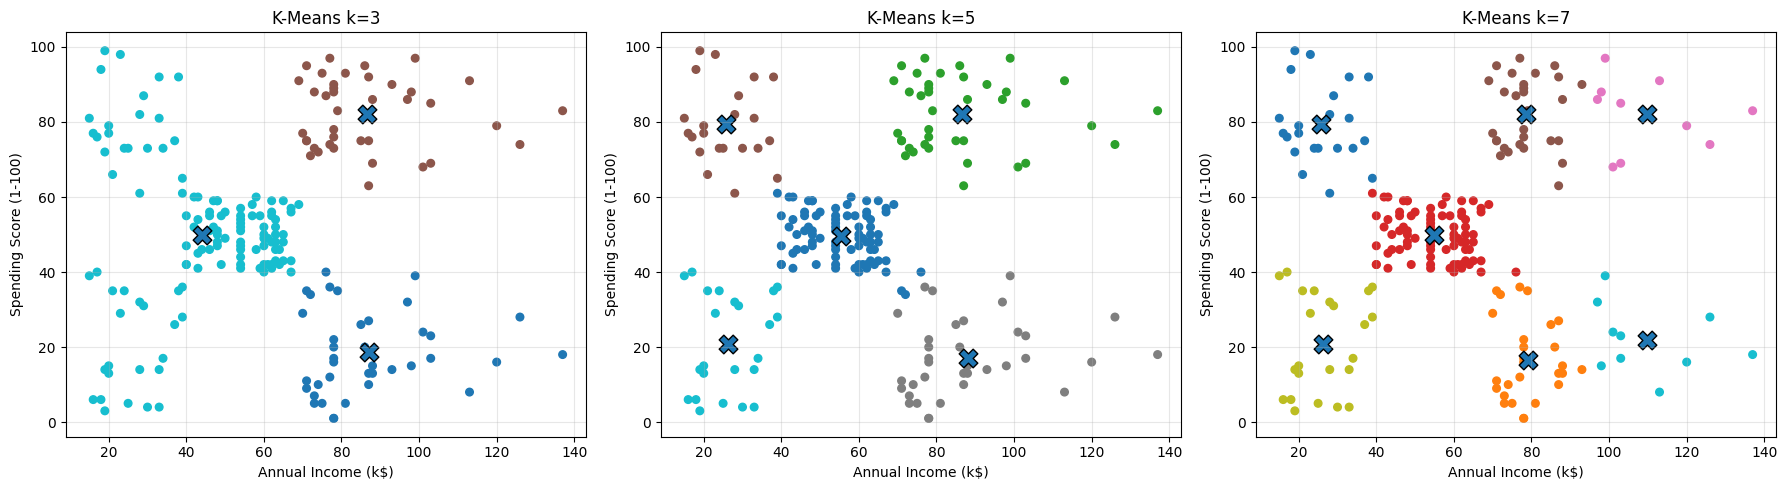

In [6]:
k_values = [3, 5, 7]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
summary_rows = []

for ax, k in zip(axes, k_values):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_mall)
    ax.scatter(X_mall.iloc[:, 0], X_mall.iloc[:, 1], c=labels, cmap="tab10", s=30)
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], marker="X", s=180, edgecolor="black")
    ax.set_title(f"K-Means k={k}")
    ax.set_xlabel("Annual Income (k$)")
    ax.set_ylabel("Spending Score (1-100)")
    ax.grid(True, alpha=0.3)
    summary_rows.append({"k": k, "inertia": km.inertia_})

plt.tight_layout()
plt.savefig(OUT_DIR / "beginner_02_kmeans_k_3_5_7.png", dpi=160)
plt.show()

pd.DataFrame(summary_rows).to_csv(OUT_DIR / "beginner_kmeans_k_3_5_7_summary.csv", index=False)

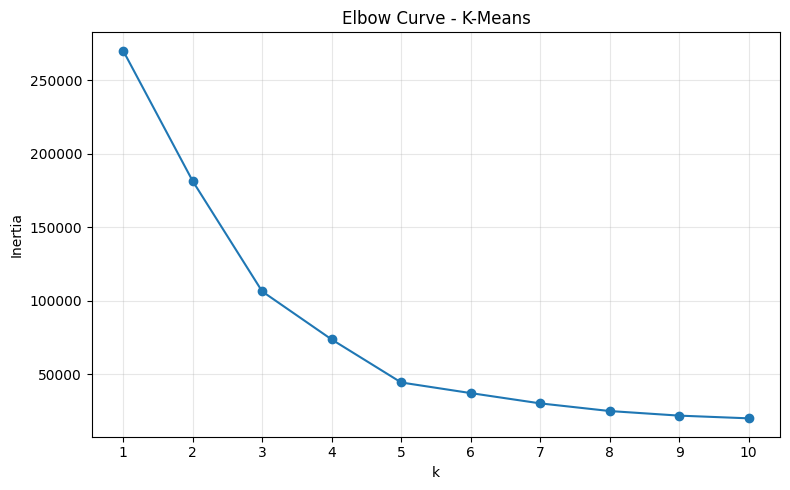

,k,inertia
0,1,269981.280000
1,2,181363.595960
2,3,106348.373062
3,4,73679.789039
4,5,44448.455448
5,6,37233.814511
6,7,30241.343618
7,8,25036.417604
8,9,21916.794790
9,10,20072.070939


In [7]:
elbow_rows = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_mall)
    elbow_rows.append({"k": k, "inertia": km.inertia_})

elbow_df = pd.DataFrame(elbow_rows)
elbow_df.to_csv(OUT_DIR / "beginner_elbow_inertia.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(elbow_df["k"], elbow_df["inertia"], marker="o")
plt.xticks(range(1, 11))
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Curve - K-Means")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "beginner_03_elbow_curve.png", dpi=160)
plt.show()

elbow_df

In [8]:
final_k = 5
final_model = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df_out = df.copy()
df_out["cluster_k5"] = final_model.fit_predict(X_mall)
df_out.to_csv(OUT_DIR / "beginner_mall_customers_with_clusters.csv", index=False)
df_out[["cluster_k5"] + required_cols].groupby("cluster_k5").agg(["count", "mean", "min", "max"])

Annual Income (k$)                     Spending Score (1-100)  \
                        count       mean min  max                  count   
cluster_k5                                                                 
0                          81  55.296296  39   76                     81   
1                          39  86.538462  69  137                     39   
2                          22  25.727273  15   39                     22   
3                          35  88.200000  70  137                     35   
4                          23  26.304348  15   39                     23   

                               
                 mean min max  
cluster_k5                     
0           49.518519  34  61  
1           82.128205  63  97  
2           79.363636  61  99  
3           17.114286   1  39  
4           20.913043   3  40